# **FCHEV model validation**
**Creators:**
# **Ali Baghani**
**ORCid:**
**https://orcid.org/0000-0002-8423-970X**

# **Mohammad Hosein Kazemi**
**ORCid:**
**https://orcid.org/0009-0009-5610-0346**


**This section evaluates the accuracy of the modeling estimates. To achieve this, the results for fuel consumption and the SOC the primary simulation output parameters are compared with those of experimental data.**

# **Loading data**



In [18]:
import pandas as pd

def load_csv(file_name):
    try:
        df = pd.read_csv(file_name)
        return df
    except FileNotFoundError:
        print(f"File not found: {file_name}")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None
file_name = r'C:\Users\ALMANAR 2\Documents\Ali\Code for Github\Intigration of Component sizing and DRL-based EMS\FCHEV model validation/61712010.csv'
loaded_data = load_csv(file_name)


# **Extraction of :**

1.   Time
2.   speed
3. acceleration
4. displacement





Variable Time (in sec):
[-30.0, -29.9, -29.8, -29.7, -29.6, -29.5, -29.4, -29.3, -29.2, -29.1, -29.0, -28.9, -28.8, -28.7, -28.6, -28.5, -28.4, -28.3, -28.2, -28.1, -28.0, -27.9, -27.8, -27.7, -27.6, -27.5, -27.4, -27.3, -27.2, -27.1, -27.0, -26.9, -26.8, -26.7, -26.6, -26.5, -26.4, -26.3, -26.2, -26.1, -26.0, -25.9, -25.8, -25.7, -25.6, -25.5, -25.4, -25.3, -25.2, -25.1, -25.0, -24.9, -24.8, -24.7, -24.6, -24.5, -24.4, -24.3, -24.2, -24.1, -24.0, -23.9, -23.8, -23.7, -23.6, -23.5, -23.4, -23.3, -23.2, -23.1, -23.0, -22.9, -22.8, -22.7, -22.6, -22.5, -22.4, -22.3, -22.2, -22.1, -22.0, -21.9, -21.8, -21.7, -21.6, -21.5, -21.4, -21.3, -21.2, -21.1, -21.0, -20.9, -20.8, -20.7, -20.6, -20.5, -20.4, -20.3, -20.2, -20.1, -20.0, -19.9, -19.8, -19.7, -19.6, -19.5, -19.4, -19.3, -19.2, -19.1, -19.0, -18.9, -18.8, -18.7, -18.6, -18.5, -18.4, -18.3, -18.2, -18.1, -18.0, -17.9, -17.8, -17.7, -17.6, -17.5, -17.4, -17.3, -17.2, -17.1, -17.0, -16.9, -16.8, -16.7, -16.6, -16.5, -16.4, -16.3, -16.2, -1

Text(0.5, 1.0, 'Velocity, acceleration , and displacement over Time')

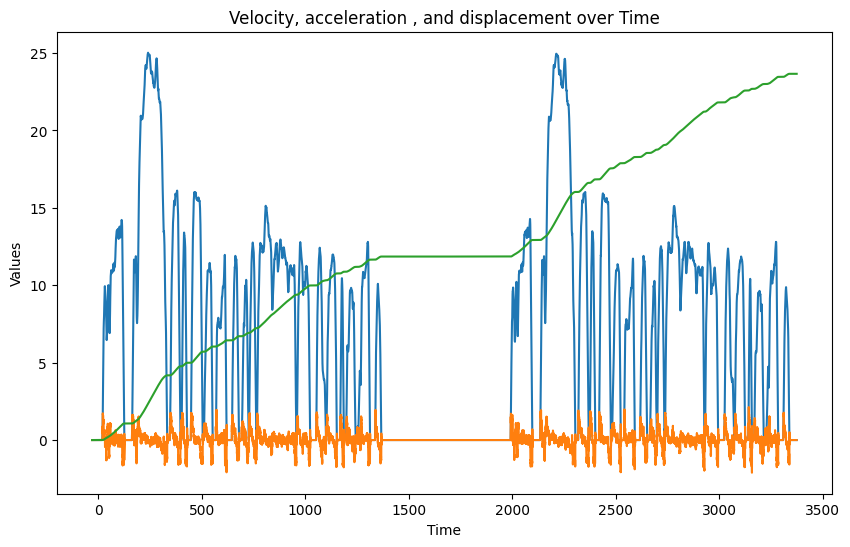

In [19]:
column_T = loaded_data.iloc[:, 0]
column_V = loaded_data.iloc[:, 1]
column_V=column_V*0.440704   #mph to mps
Time = list(column_T)
Vel = list(column_V)

a = []
D = []
disp=0
for i in range(0, len(Time)):
    result_a = (Vel[i]-Vel[i-1]) / ((Time[i] - Time[i - 1]))
    a.append(result_a)
    result_D = Vel[i] * ( (Time[i] - Time[i - 1]) )
    D.append(result_D)

from itertools import accumulate
disp = list(accumulate(D))
disp_km = [value * 0.001 for value in disp]


print("Variable Time (in sec):")
print(Time)
print("Variable Speed (in m/s):")
print(Vel)
print("Variable acc (in m/s^2):")
print(a)
print("Variable disp (in meter):")
print(D)
print("Variable total disp (in meter):")
print(disp)

import matplotlib.pyplot as plt
min_length = min(len(Time), len(Vel), len(a), len(disp_km))

plt.figure(figsize=(10, 6))
plt.plot(Time[:min_length], Vel[:min_length], label='Velocity')
plt.plot(Time[:min_length], a[:min_length], label='acc')
plt.plot(Time[:min_length], disp_km[:min_length], label='disp')

plt.xlabel('Time')
plt.ylabel('Values')
plt.title('Velocity, acceleration , and displacement over Time')



# **Vehicle dinamic model**

In this section, the one-dimensional dynamic model of the car is simulated to calculate the amount of output torque, rotational speed, and rotational acceleration of the output shaft from the gearbox.

**Input:**


1. Time
2. Speed
3. Acceleration

**Output:**


1.   Gear box output torque (input torque to the wheels)
2.   Rotational speed of the output shaft of the gearbox (rotational speed of the input shaft to the wheels)
3. Rotational acceleration of the output shaft of the gearbox (rotational acceleration of the input shaft to the wheels)





(0.0, 1400.0)

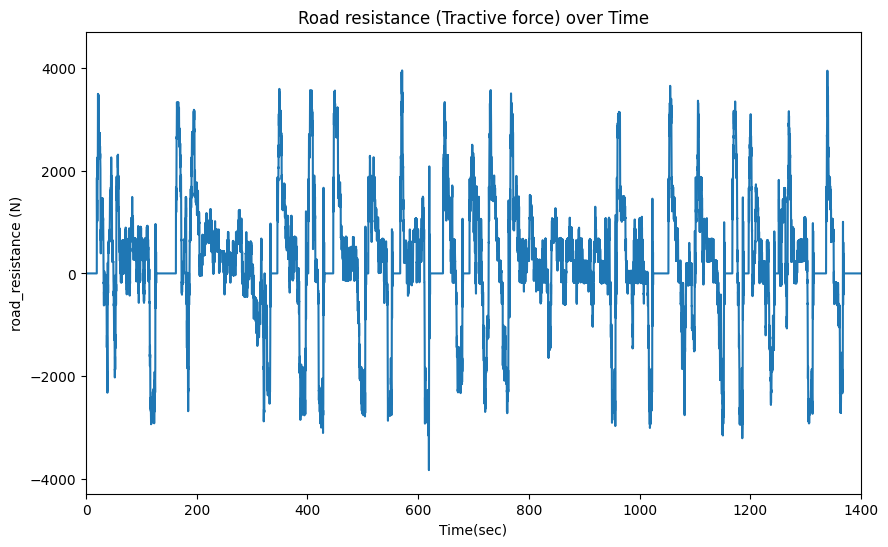

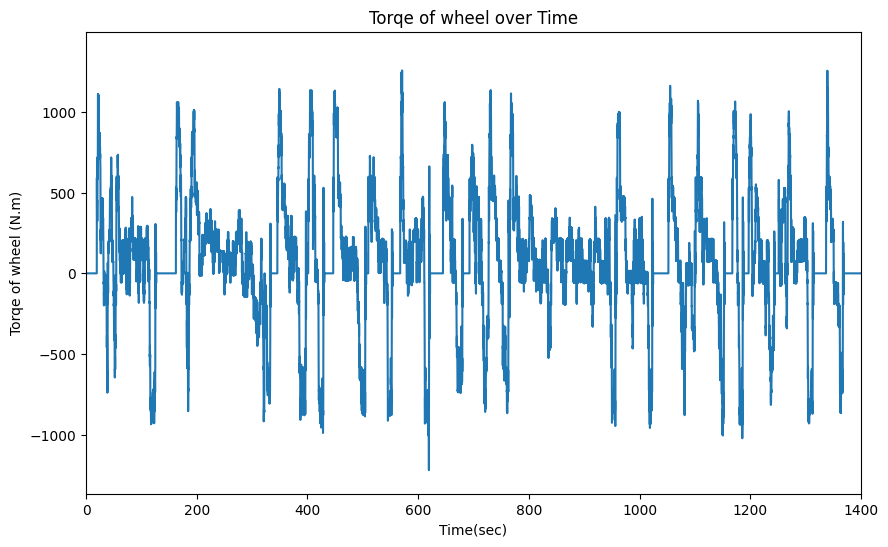

In [20]:
mass_vehicle=1930 #kg
g=9.81
c_d=0.29
A_f=2.23
rho=1.2
R_wheel=0.316
f_r=0.01
J_wheel=0.32
theta=0     #road slop

import math

cos_theta = math.cos(math.radians(theta))
rolling_resistance=[]
for i in range (0 ,len(Time)):
  if Vel[i]>0:
    result_rolling_resistance=mass_vehicle*g*f_r*cos_theta
  else:
    result_rolling_resistance=0
  rolling_resistance.append(result_rolling_resistance)

aerodynamic_resistance = []
for i in range(0, len(Time)):
  result_ar = 0.5*rho*c_d*A_f*Vel[i]**2
  aerodynamic_resistance.append(result_ar)

sin_theta = math.sin(math.radians(theta))
gravity_force=mass_vehicle*g*sin_theta

inertia_force=[]
for i in range(0, len(Time)):
  result_if=mass_vehicle*a[i]
  inertia_force.append(result_if)

road_resistance=[]
for i in range(0, len(Time)):
  result_rr = rolling_resistance[i]+gravity_force+aerodynamic_resistance[i]+inertia_force[i]
  road_resistance.append(result_rr)

min_length = min(len(Time), len(road_resistance))

plt.figure(figsize=(10, 6))
plt.plot(Time[:min_length], road_resistance[:min_length], label='Road resistance')


plt.xlabel('Time(sec)')
plt.ylabel('road_resistance (N)')
plt.title('Road resistance (Tractive force) over Time')
plt.xlim(0,1400)

tractiv_torqe=[]
omega_dot=[]
omega=[]
torqe_wheel=[]
for i in range(0, len(Time)):
  result_tt=road_resistance[i]*R_wheel
  tractiv_torqe.append(result_tt)
  result_o=Vel[i]/R_wheel
  omega.append(result_o)
  result_om=a[i]/R_wheel
  omega_dot.append(result_om)
  result_tw=4*J_wheel*omega_dot[i]+tractiv_torqe[i]
  torqe_wheel.append(result_tw)

plt.figure(figsize=(10, 6))
plt.plot(Time, torqe_wheel, label='Road resistance')
plt.xlabel('Time(sec)')
plt.ylabel('Torqe of wheel (N.m)')
plt.title('Torqe of wheel over Time')
plt.xlim(0,1400)


# **Gearbox model**

In this section, gearbox and differential conversion coefficients are modeled.

**Inputs:**

1. The output torque of the wheels
2. rotational speed of the wheels
3. rotational acceleration of the wheels
**Outputs:**
1. Input torque to the electric motor
2. Rotational speed of the output shaft of the electric motor
3. Rotational acceleration of the output shaft

(0.0, 1400.0)

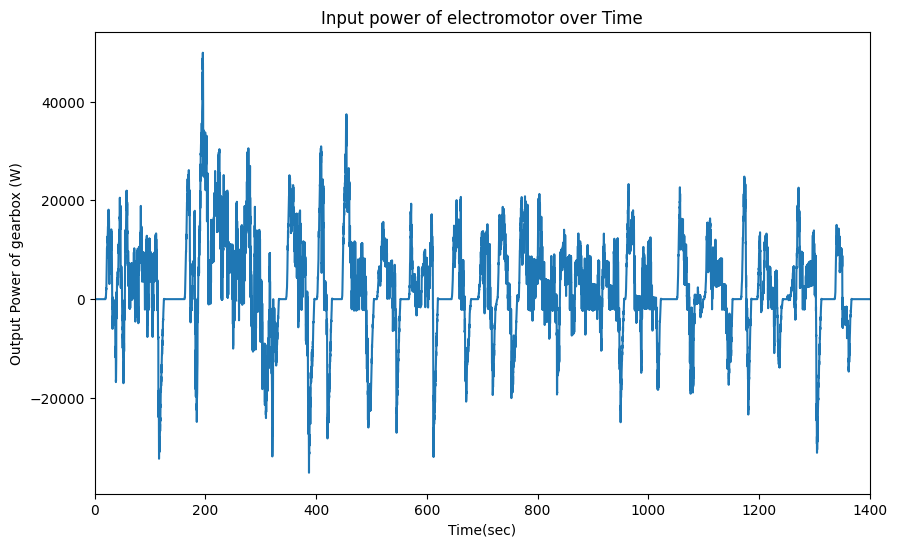

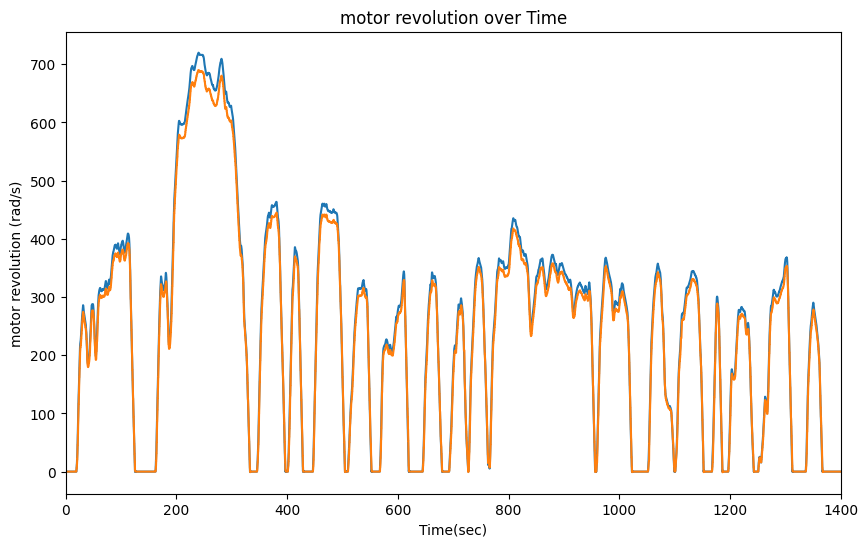

In [21]:
GR=9.09
eta_gb=0.98
omega_EM=[]
omega_dot_EM=[]
tprqe_gb=[]
power_gb=[]
for i in range (0, len(Time)):
  result_o_EM=omega[i]*GR
  omega_EM.append(result_o_EM)
  result_om_EM=omega_dot[i]*GR
  omega_dot_EM.append(result_om_EM)
  if (torqe_wheel[i]>=0):
    result_tgb=torqe_wheel[i]/(eta_gb*GR)
  else:
    result_tgb=(torqe_wheel[i]*eta_gb)/GR
  tprqe_gb.append(result_tgb)
  result_pgb=tprqe_gb[i]*omega_EM[i]
  power_gb.append(result_pgb)

column_motor_revolution = loaded_data.iloc[:, 55]
column_motor_revolution = column_motor_revolution * ((2*3.14)/60)
motor_revolution_exp = list(column_motor_revolution)

plt.figure(figsize=(10, 6))
plt.plot(Time, power_gb, label='electromotor power')
plt.xlabel('Time(sec)')
plt.ylabel('Output Power of gearbox (W)')
plt.title('Input power of electromotor over Time')
plt.xlim(0,1400)

plt.figure(figsize=(10, 6))
plt.plot(Time, omega_EM, label='motor revolution')
plt.plot(Time, motor_revolution_exp, label='Experimental motor revolution')
plt.xlabel('Time(sec)')
plt.ylabel('motor revolution (rad/s)')
plt.title('motor revolution over Time')
plt.xlim(0,1400)

#  **Electric machine**

In this, by using the map of the electric machine, which is extracted from the experimental data, the efficiency of the electric machine is read in each revolution and operating torque, and it is used to calculate the electric power input to it.

**Inputs:**
1. Output torque from the electric motor shaft
2. Rotational speed of the electric motor shaft
3. Rotational acceleration of the electric motor shaft

**Outputs:**
1. The total electric power required by the electric motor in state I

C:\Windows\Temp\ipykernel_25248\1366518224.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  result_3=float(interp_function(omega_EM[i],torqe_EM[i]))


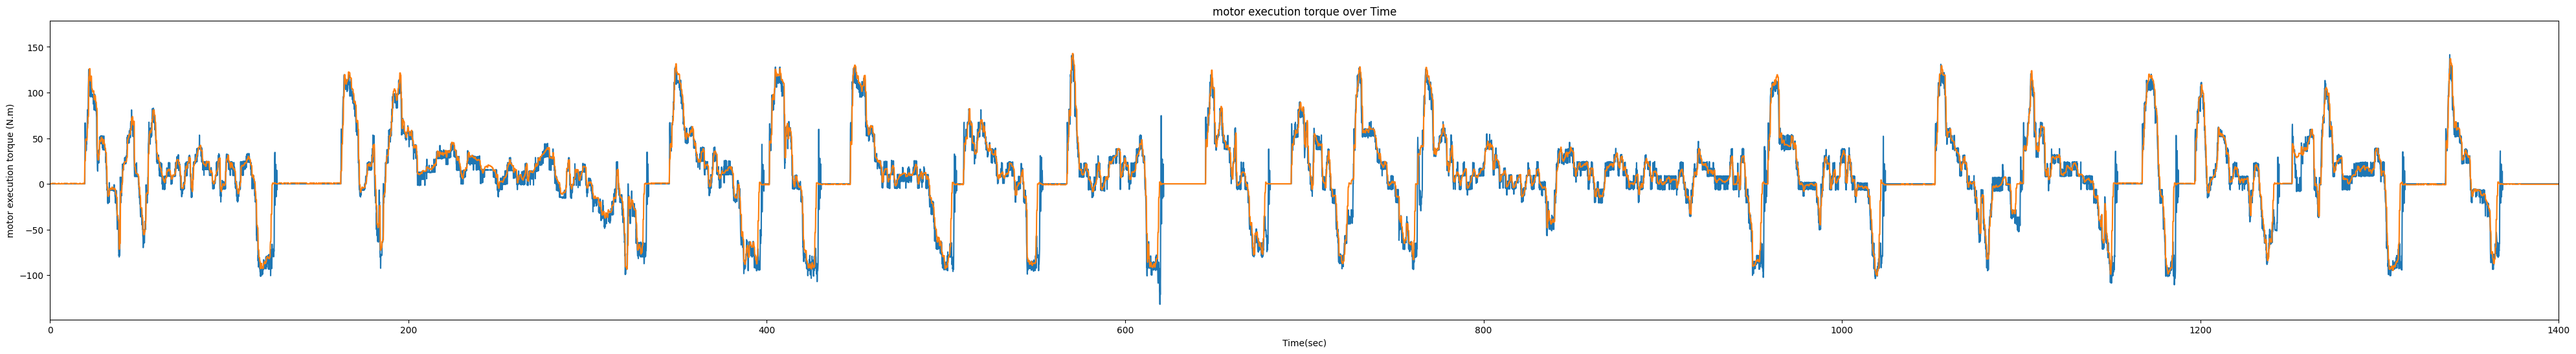

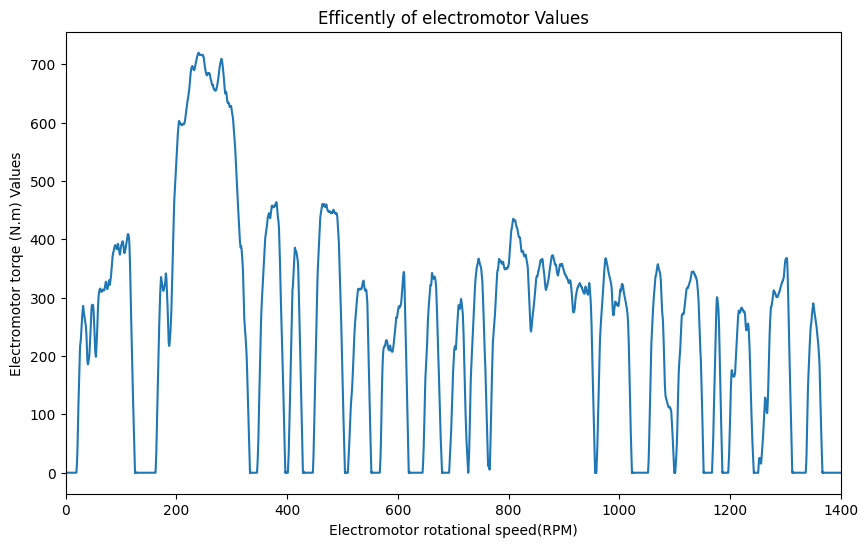

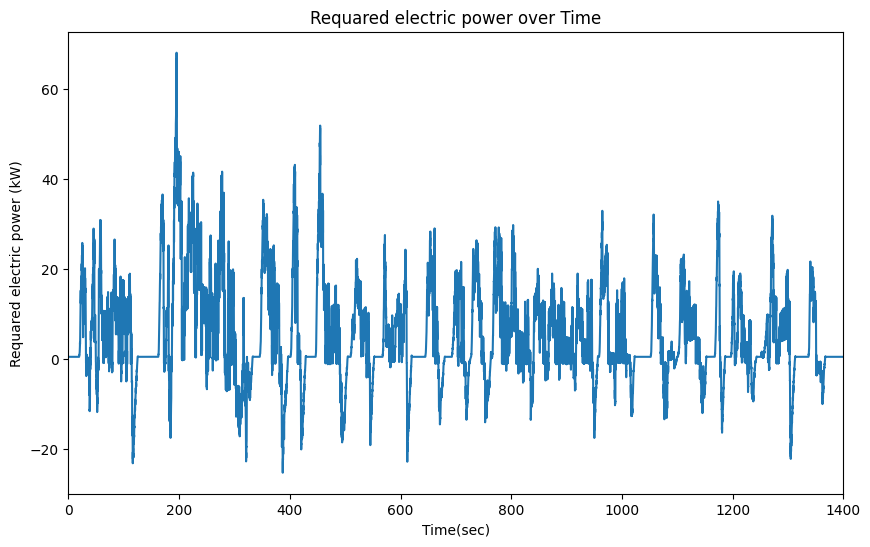

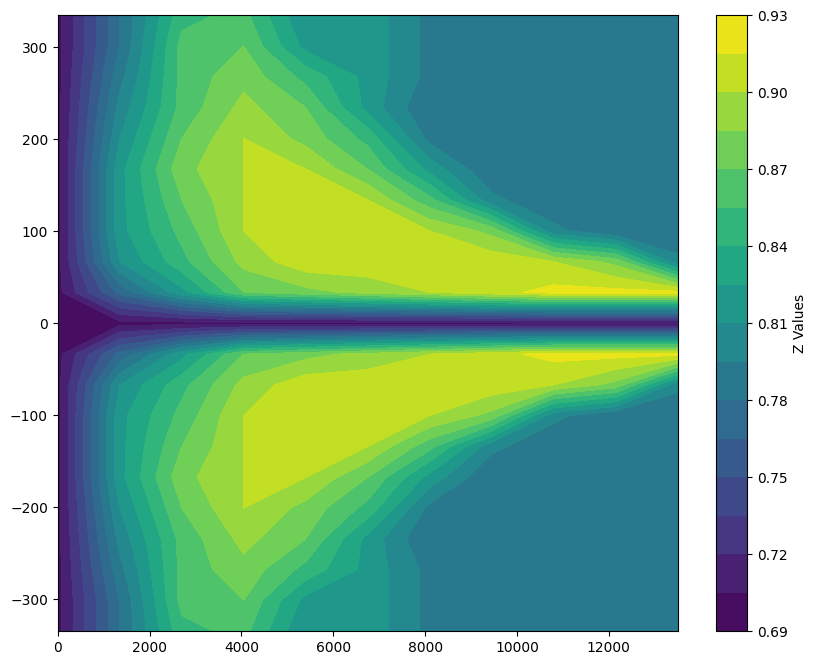

In [22]:
J_em=0.008
P_axu=440
import numpy as np

class OneDimensionalLookupTable:
    def __init__(self, x_values, y_values):
        self.x_values = np.array(x_values)
        self.y_values = np.array(y_values)

    def lookup(self, input_value):
        output_value = np.interp(input_value, self.x_values, self.y_values)
        return output_value

data_EM_speed = [94.92188,1202.344,2119.919,3227.351,4366.413,4777.731,5600.394,6517.976,7403.913,8732.813,10156.64,11675.39,13573.85,15219.09,16737.84,17940.29]
data_max_EM_torqe = [561.3026,563.9893,563.9189,561.0647,558.2072,511.066,433.4113,375.1481,330.7422,277.9897,239.0862,208.4873,177.8599,161.1085,144.3662,133.1903]
lookup_table_max_EM_torqe = OneDimensionalLookupTable(data_EM_speed, data_max_EM_torqe)

max_torqe_EM=[]
torqe_EM=[]
power_EM=[]
EE=[]
for i in range (0, len(Time)):
  result_max_tem=lookup_table_max_EM_torqe.lookup((omega_EM[i]*60/(2*3.14)))
  max_torqe_EM.append(result_max_tem)
  result_1=(J_em*omega_dot_EM[i])+tprqe_gb[i]

  if result_1 > max_torqe_EM[i]:
    torqe_EM.append(max_torqe_EM[i])
  elif -max_torqe_EM[i] <= result_1 and result_1 <= max_torqe_EM[i]:
    torqe_EM.append(result_1)
  else :
    torqe_EM.append(-max_torqe_EM[i])

  result_2=torqe_EM[i]*omega_EM[i]
  power_EM.append(result_2)

from scipy.interpolate import RectBivariateSpline
# Data for efficenly of EM
x_values = np.array([0, 1350, 2700, 4050, 5400, 6750, 8100, 9450, 10800, 12150, 13500])
y_values = np.array([-335, -301.5, -268, -234.5, -201, -167.5, -134, -100.5, -67, -33.5, 0, 33.5, 67, 100.5, 134, 167.5, 201, 234.5, 268, 301.5, 335])
z_values = np.array([
    [0.7, 0.78, 0.85, 0.86, 0.81, 0.82, 0.79, 0.78, 0.78, 0.78, 0.78],
    [0.7, 0.78, 0.86, 0.87, 0.82, 0.82, 0.79, 0.78, 0.78, 0.78, 0.78],
    [0.7, 0.79, 0.86, 0.88, 0.85, 0.82, 0.79, 0.78, 0.78, 0.78, 0.78],
    [0.7, 0.8, 0.86, 0.89, 0.87, 0.82, 0.78, 0.78, 0.78, 0.78, 0.78],
    [0.7, 0.81, 0.87, 0.9, 0.88, 0.85, 0.79, 0.78, 0.78, 0.78, 0.78],
    [0.7, 0.82, 0.88, 0.9, 0.9, 0.87, 0.82, 0.78, 0.78, 0.78, 0.78],
    [0.7, 0.82, 0.87, 0.9, 0.91, 0.9, 0.86, 0.8, 0.78, 0.78, 0.78],
    [0.7, 0.82, 0.86, 0.9, 0.91, 0.91, 0.9, 0.88, 0.8, 0.78, 0.78],
    [0.7, 0.81, 0.85, 0.89, 0.91, 0.91, 0.91, 0.91, 0.9, 0.88, 0.8],
    [0.7, 0.77, 0.82, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.92, 0.92],
    [0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7],
    [0.7, 0.77, 0.82, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.92, 0.92],
    [0.7, 0.81, 0.85, 0.89, 0.91, 0.91, 0.91, 0.91, 0.9, 0.88, 0.8],
    [0.7, 0.82, 0.86, 0.9, 0.91, 0.91, 0.9, 0.88, 0.8, 0.78, 0.78],
    [0.7, 0.82, 0.87, 0.9, 0.91, 0.9, 0.86, 0.8, 0.78, 0.78, 0.78],
    [0.7, 0.82, 0.88, 0.9, 0.9, 0.87, 0.82, 0.78, 0.78, 0.78, 0.78],
    [0.7, 0.81, 0.87, 0.9, 0.88, 0.85, 0.79, 0.78, 0.78, 0.78, 0.78],
    [0.7, 0.8, 0.86, 0.89, 0.87, 0.82, 0.78, 0.78, 0.78, 0.78, 0.78],
    [0.7, 0.79, 0.86, 0.88, 0.85, 0.82, 0.79, 0.78, 0.78, 0.78, 0.78],
    [0.7, 0.78, 0.86, 0.87, 0.82, 0.82, 0.79, 0.78, 0.78, 0.78, 0.78],
    [0.7, 0.78, 0.85, 0.86, 0.81, 0.82, 0.79, 0.78, 0.78, 0.78, 0.78],

])

x_mesh, y_mesh = np.meshgrid(x_values, y_values)
interp_function = RectBivariateSpline(x_values, y_values, z_values.T, kx=1, ky=1)

eff_EM=[]
power_req=[]
for i in range(0, len(Time)):
  result_3=float(interp_function(omega_EM[i],torqe_EM[i]))
  eff_EM.append(result_3)
  if torqe_EM[i] >= 0:
    result_4=((power_EM[i]/eff_EM[i])+P_axu)*0.001
  else:
    result_4=((power_EM[i]*eff_EM[i])+P_axu)*0.001

  power_req.append(result_4)

column_motor_execution_torque = loaded_data.iloc[:, 57]
motor_execution_torque_exp = list(column_motor_execution_torque)

plt.figure(figsize=(50, 6))
plt.plot(Time, torqe_EM, label='motor execution torque')
plt.plot(Time, motor_execution_torque_exp, label='Experimental motor execution torque ')
plt.xlabel('Time(sec)')
plt.ylabel('motor execution torque (N.m)')
plt.title('motor execution torque over Time')
plt.xlim(0,1400)

plt.figure(figsize=(10, 6))
plt.plot(Time, omega_EM, label='Electromotor rotational speed')
plt.xlabel('Electromotor rotational speed(RPM)')
plt.ylabel('Electromotor torqe (N.m) Values')
plt.title('Efficently of electromotor Values')
plt.xlim(0,1400)

plt.figure(figsize=(10, 6))
plt.plot(Time, power_req, label='Requared electric power')
plt.xlabel('Time(sec)')
plt.ylabel('Requared electric power (kW)')
plt.title('Requared electric power over Time')
plt.xlim(0,1400)

plt.figure(figsize=(10, 8))
contour_plot = plt.contourf(x_values, y_values, z_values, cmap='viridis', levels=20)
plt.colorbar(contour_plot, label='Z Values')

# **Energy mangement stratgy & Battery model**
In this section, we reconstruct the energy distribution policy in the reference car, Toyota Mirai generation one.
This is done by comprehensive laboratory data in such a way that the power of the electric motor was drawn in terms of battery power and fuel cell power and the correlation between them was obtained. Now, by using conditional commands, the way of energy distribution in the reference car can be reconstructed
In this model, we obtain the required power of the electric motor to the power of the battery and fuel cell



*   It is noteworthy that according to the way EMS decides the charging mode, it is necessary to have a couple battery model.

**Inputs:**


1.   Required power
2.   State of Charge (SOC) of battery

**Outputs:**

1. Power of battery
2. Power of fuel cell
3. State of charge



(0.0, 1400.0)

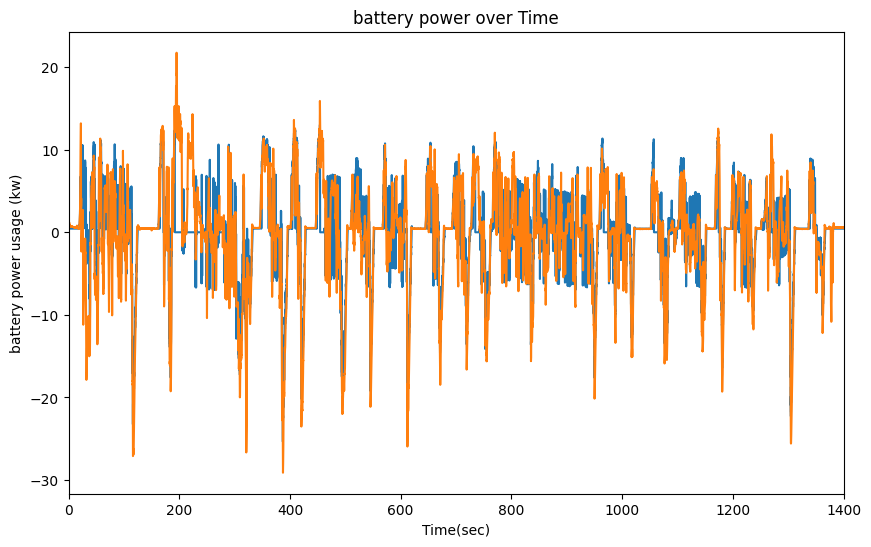

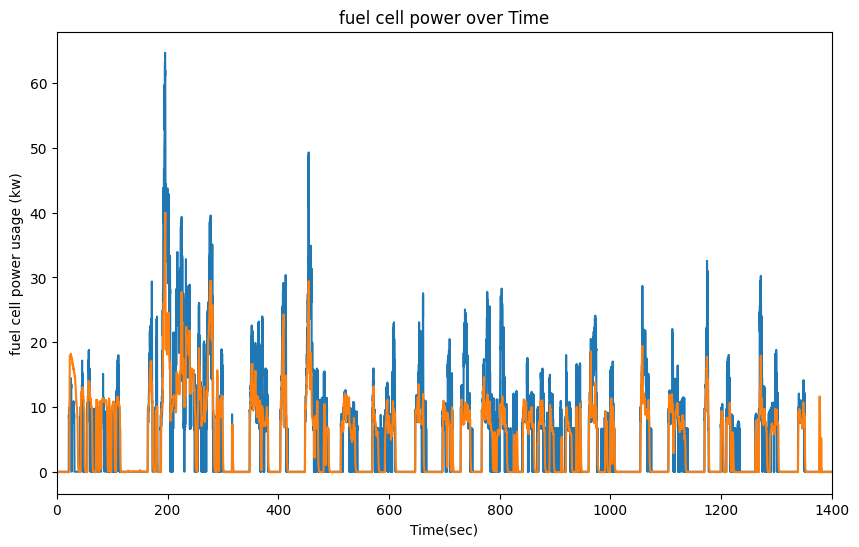

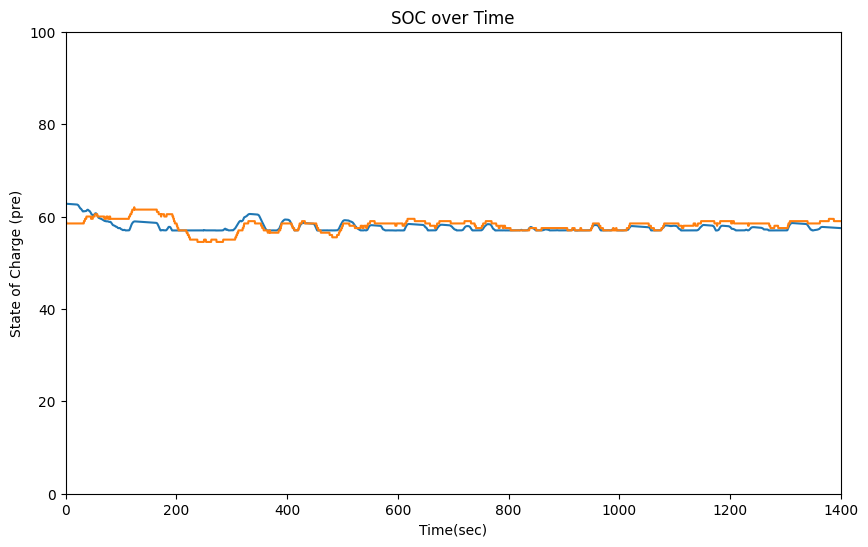

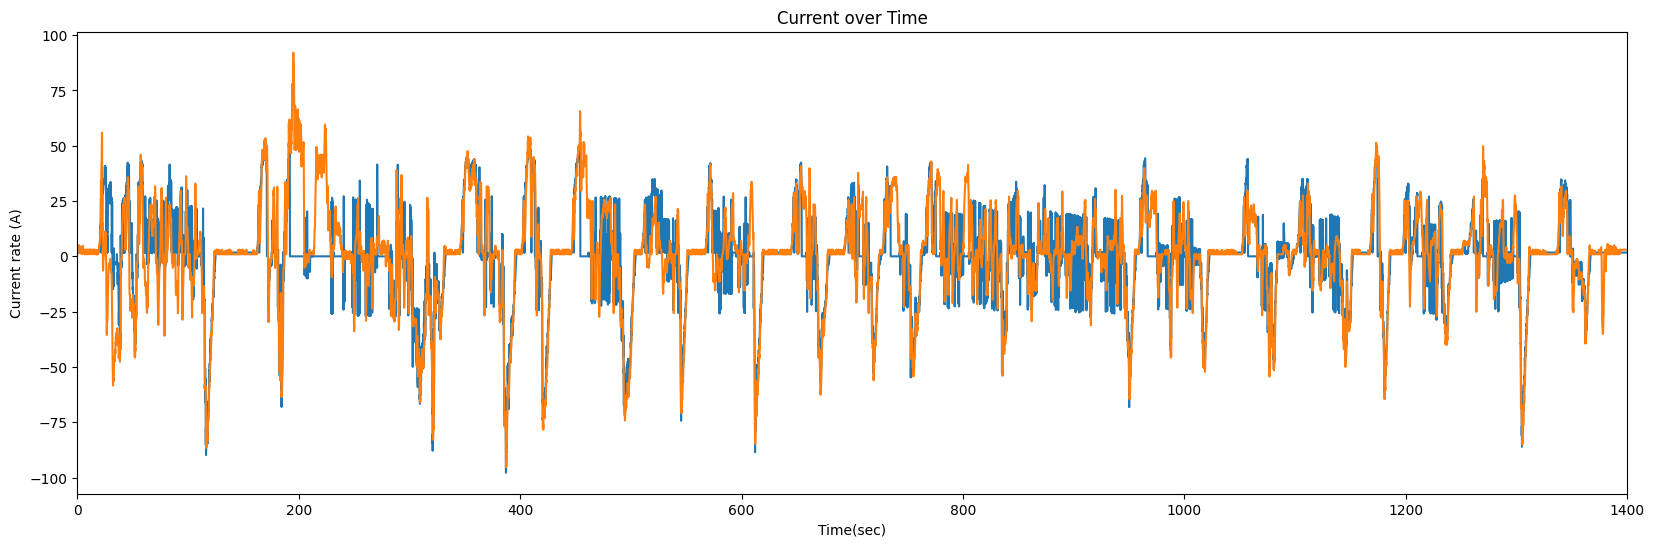

In [23]:
def calculate_power(P_req, SOC_in):
    if P_req < 0:
        P_fc = 0
        P_bat = P_req
    elif P_req == 0:
        P_fc = 0
        P_bat = 0
    elif 0 < P_req < 7.000 and SOC_in < 57:
        P_fc = 7.000
        P_bat = P_req - 7.000
    elif 0 <= P_req < 7.000 and SOC_in >= 57:
        P_fc = 0
        P_bat = P_req
    elif 7.000 <= P_req < 11.000:
        P_bat = 0.440
        P_fc = P_req - 0.440
    elif 11.000 <= P_req and SOC_in < 57:
        P_bat = 0
        P_fc = P_req
    elif SOC_in >= 57 and 11.000 <= P_req < 14.000:
        P_fc = -0.79 * P_req + 19.11
        P_bat = P_req - P_fc
    elif SOC_in >= 57 and 14.000 <= P_req < 16.500:
        P_fc = 0.5 * P_req + 0.925
        P_bat = P_req - P_fc
    elif SOC_in >= 57 and 16.500 <= P_req < 20.700:
        P_fc = 0.6265 * P_req - 1.168
        P_bat = P_req - P_fc
    elif SOC_in >= 57 and 20.700 <= P_req < 23.500:
        P_fc = 0.92 * P_req - 7.2
        P_bat = P_req - P_fc
    elif SOC_in >= 57 and 23.500 <= P_req:
        P_fc = 0.89 * P_req - 7.7285
        P_bat = P_req - P_fc
    return P_bat, (P_fc*0.95)

power_bat=[]
power_fc=[]
P_disc=[]
P_cha=[]
SOC_0=63
SOC_in=[]
SOC_in.append(SOC_0)
Q_nom=6.5*3600
OCV=[]
R_disc=[]
R_cha=[]
I_disc=[]
I_cha=[]
deltaSOC=[]
SOC=[]
for i in range(0, len(Time)):
  currentpower_bat, currentpower_FC = calculate_power(power_req[i], SOC_in[i])
  power_bat.append(currentpower_bat)
  power_fc.append(currentpower_FC)

  if power_bat[i] >= 0:
    rsult_P_batt=power_bat[i]*1000
    P_disc.append(rsult_P_batt)
    P_cha.append(0)
  else:
    rsult_P_batt=power_bat[i]*(-1000)
    P_disc.append(0)
    P_cha.append(rsult_P_batt)

  result_5=1722.4*((SOC_in[i]*0.01)**5)-4747.5*((SOC_in[i]*0.01)**4)+4891.9*((SOC_in[i]*0.01)**3)-2312.1*((SOC_in[i]*0.01)**2)+525.72*(SOC_in[i]*0.01)+200.06
  result_6=0.0188*((SOC_in[i]*0.01)**4)-0.0547*((SOC_in[i]*0.01)**3)+0.0765*((SOC_in[i]*0.01)**2)-0.0457*((SOC_in[i]*0.01))+0.0349
  result_7=0.0056*((SOC_in[i]*0.01)**4)-0.0254*((SOC_in[i]*0.01)**3)+0.0372*((SOC_in[i]*0.01)**2)-0.0203*((SOC_in[i]*0.01))+0.0223
  OCV.append(result_5)
  R_disc.append(result_6)
  R_cha.append(result_7)
  result_8=( OCV[i]-math.sqrt((OCV[i]**2)-4*R_disc[i]*P_disc[i]))/(2*R_disc[i])
  result_9=(-OCV[i]+math.sqrt((OCV[i]**2)+4*R_cha[i] *P_cha[i]))/(2*R_cha[i])
  I_disc.append(result_8)
  I_cha.append(result_9)
  result_10=((I_cha[i]*0.1)/Q_nom)-(((I_disc[i]**1.1)*0.1)/Q_nom)
  deltaSOC.append(result_10)
  result_11=((deltaSOC[i]*100)+SOC_in[i])
  SOC_in.append(result_11)

column_P_bat = loaded_data.iloc[:, 23]
column_P_fc  = loaded_data.iloc[:, 26]
column_SOC  = loaded_data.iloc[:, 136]
P_bat_exp = list(column_P_bat)
P_fc_exp  = list(column_P_fc)
SOC_exp  = list(column_SOC)

plt.figure(figsize=(10, 6))
plt.plot(Time, power_bat, label='battery power usage')
plt.plot(Time, P_bat_exp, label='Experimental battery power usage ')
plt.xlim(0,1400)
plt.xlabel('Time(sec)')
plt.ylabel('battery power usage (kw)')
plt.title('battery power over Time')

plt.figure(figsize=(10, 6))
plt.plot(Time, power_fc, label='fuel cell power usage')
plt.plot(Time, P_fc_exp, label='Experimental fuel cell power usage')
plt.xlim(0,1400)
plt.xlabel('Time(sec)')
plt.ylabel('fuel cell power usage (kw)')
plt.title('fuel cell power over Time')


plt.figure(figsize=(10, 6))
plt.plot(Time, SOC_in[:-1], label='State of Charge')
plt.plot(Time, SOC_exp, label='Experimental state of Charge' )
plt.xlabel('Time(sec)')
plt.ylim(0, 100)
plt.xlim(0,1400)
plt.ylabel('State of Charge (pre)')
plt.title('SOC over Time')

column_I_bat_EX = loaded_data.iloc[:, 137]
I_bat_EX=list(column_I_bat_EX)
I_bat=[]
for i in range(0, len(Time)):
  result_12=I_disc[i]-I_cha[i]
  I_bat.append(result_12)
plt.figure(figsize=(20, 6))
plt.plot(Time, I_bat)
plt.plot(Time, I_bat_EX)
plt.xlabel('Time(sec)')
plt.ylabel('Current rate (A)')
plt.title('Current over Time')
plt.xlim(0,1400)


# **Battery degradation model**



(0.0, 1400.0)

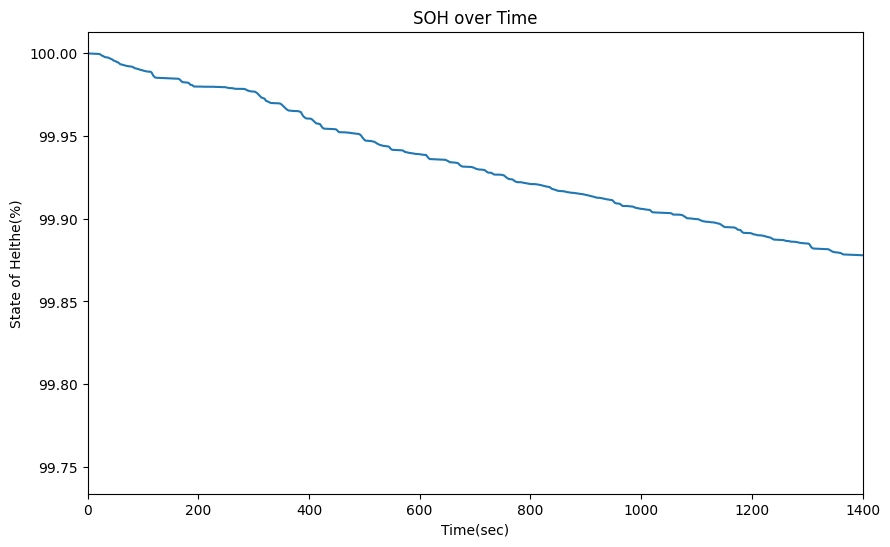

In [24]:
data_M = [31630,21681,12934,15512]
data_C =[0.5,2,6,10]
lookup_table_M = OneDimensionalLookupTable(data_C, data_M)
M=[]
C_rate=[]
Q_loss=[]
Ah_tot=[]
deltaSOH=[]
SOH=[]
cumulativeSOH=0
for i in range(0, len(Time)):
  result_C_rate=(abs((I_bat[i])/2))/6.5
  C_rate.append(result_C_rate)
  M.append(lookup_table_M.lookup(C_rate[i]))
  result_13=M[i]*math.exp((-31700+(370.3*C_rate[i]))/(8.31*(273.15+30)))
  Q_loss.append(result_13)
  result_14=(20/(Q_loss[i]))**0.55
  Ah_tot.append(result_14)
  result_15=-(abs(I_bat[i]))/(Ah_tot[i]*3600*2)
  deltaSOH.append(result_15)
  cumulativeSOH += 0.1* deltaSOH[i]
  SOH.append((100+cumulativeSOH))

plt.figure(figsize=(10, 6))
plt.plot(Time, SOH, label='State of Helthe')
plt.xlabel('Time(sec)')
plt.ylabel('State of Helthe(%)')
plt.title('SOH over Time')
plt.xlim(0,1400)


#  **Fuel cell**

In this section, by using previously developed emprical relations and models, fuel cell required power is used to calculate hydrogen mass flow and fuel cell degradation.

**Inputs:**
1. fuel cell power from boost convertor

**Outputs:**
1. hydrogen consumption rate
2. fuel cell degradation rate

(0.0, 1400.0)

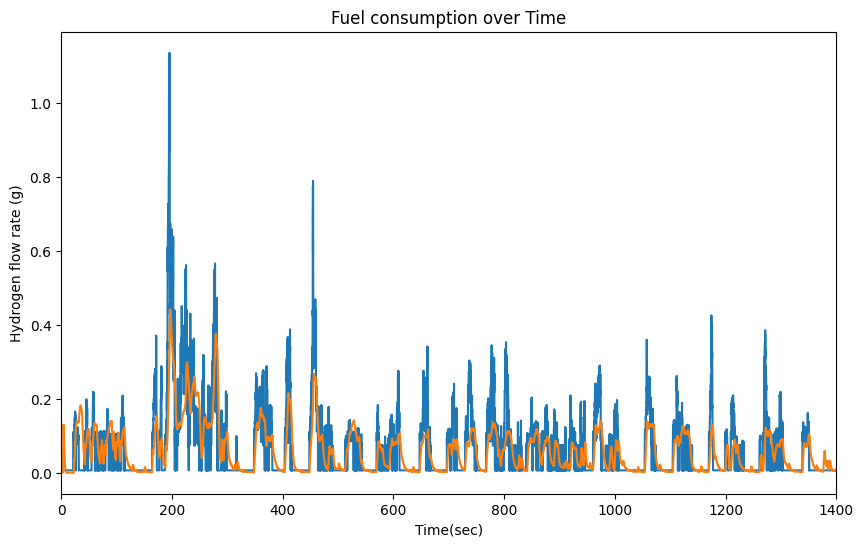

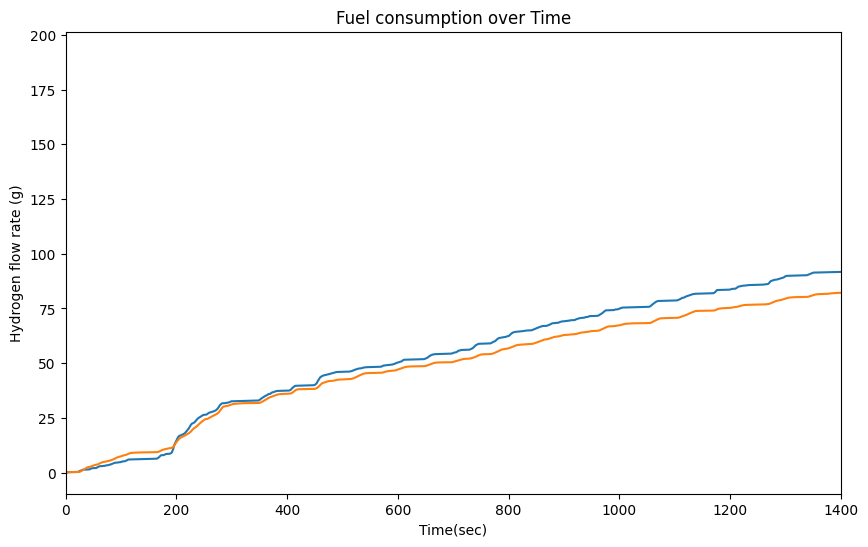

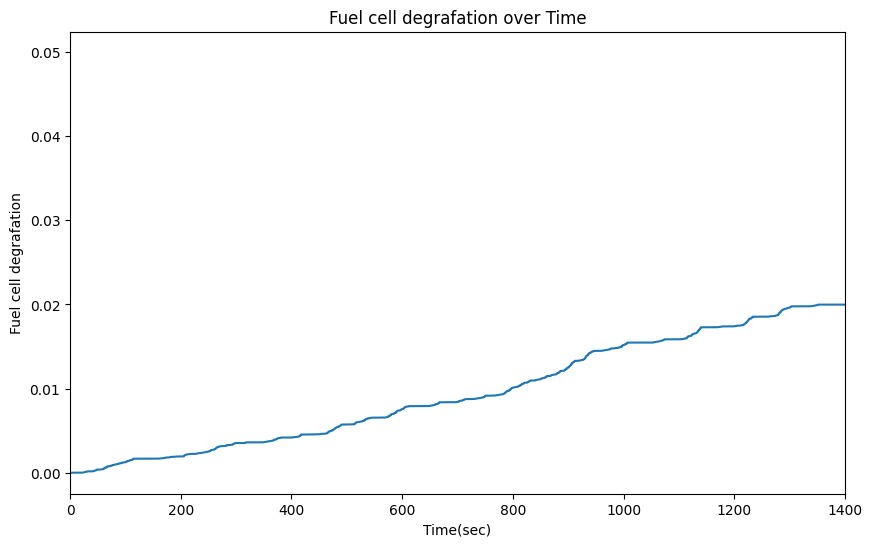

In [25]:
# we assume P_fc matrix is givan alongside that of time from previous parts
time_step = 0.1
P_max = 114
P_rel=[]
Hydrogen_Flow_rate=[]
High_load_degradation_rate=[]
Low_load_degradation_rate=[]
Load_difference_degradation_rate=[]
start_stop_degradation_rate=[]
totall_degradation_rate=[]
cumulative_Hydrogen_Flow_rate = []
cumulativeHydrogenFlowrate=0
for i in range (0, len(Time)):
  data_power = [-0.002408754,0.000263372,0.001621386,0.002984877,0.004375816,0.007075377,0.008482772,0.011182368,0.017879123,0.019292018,0.024630789,0.028660877,0.031382368,0.038035263,0.044710088,0.051362982,0.060655088,0.068594649,0.080454649,0.096223684,0.119800877,0.138094737,0.151158772,0.165504386,0.186409649,0.209921053,0.240003509,0.270128947,0.312120175,0.348910526,0.381757895,0.423787719,0.451345614,0.490675439,0.523396491,0.546941228,0.573075439,0.597917544,0.622742982,0.64889386,0.669809649,0.697318421,0.716964035,0.747144737,0.781295614,0.815429825,0.837714912,0.856046491,0.867757895,0.871657018]
  data_eta_stack = [0.566706,0.570041,0.573379,0.577135,0.582978,0.588401,0.595496,0.600919,0.610511,0.618024,0.624278,0.630951,0.638044,0.644295,0.652217,0.658468,0.665549,0.669711,0.672195,0.672166,0.666279,0.658313,0.652444,0.644068,0.634845,0.623947,0.613037,0.605468,0.6008,0.600317,0.59984,0.598095,0.595123,0.587955,0.577876,0.569483,0.558163,0.548515,0.537615,0.527547,0.519159,0.51243,0.507384,0.50399,0.502676,0.50011,0.495895,0.490852,0.482063,0.478716]
  lookup_table_eta_stack = OneDimensionalLookupTable(data_power, data_eta_stack)
  data_power2 = [0.000711683,0.007193702,0.01628193,0.027991228,0.042321579,0.057973684,0.073655526,0.095878947,0.112897368,0.131237719,0.154842105,0.178454386,0.199452632,0.22175,0.245377193,0.267689474,0.291286842,0.314899123,0.335882456,0.359464912,0.383046491,0.404007895,0.424969298,0.447229825,0.469482456,0.490436842,0.511382456,0.529722807,0.550676316,0.571645614,0.59260614,0.613575439,0.635865789,0.659470175,0.681775439,0.702773684,0.723778947,0.744792982,0.76580614,0.786819298,0.807809649,0.831429825,0.855026316,0.875987719]
  data_eta_sys = [0.61072,0.616026,0.622089,0.627389,0.631928,0.634947,0.63493,0.634147,0.631092,0.626518,0.618144,0.60901,0.599879,0.591506,0.580854,0.570963,0.563347,0.554213,0.546601,0.540503,0.534405,0.52907,0.523734,0.519156,0.515337,0.51076,0.506942,0.502368,0.497791,0.491697,0.486361,0.480266,0.472652,0.464277,0.455145,0.446014,0.436124,0.425475,0.414826,0.404177,0.395806,0.385913,0.378297,0.372961]
  lookup_table_eta_sys = OneDimensionalLookupTable(data_power2, data_eta_sys)
  result_eta_stack = lookup_table_eta_stack.lookup((power_fc[i]/114))
  result_eta_sys = lookup_table_eta_sys.lookup((power_fc[i]/114))
  max_torqe_EM.append(result_max_tem)
  # Hydrogen flow rate calcuations

  power_th = (result_eta_stack/result_eta_sys)*power_fc[i]
  result_Hydrogen_flow_rate = 8.5e-5*(power_th**2)+9.1e-3*(power_th)+0.0064
  if power_fc[i] < 0:
    result_Hydrogen_flow_rate = 0
  Hydrogen_Flow_rate.append(result_Hydrogen_flow_rate)

  cumulativeHydrogenFlowrate += time_step*result_Hydrogen_flow_rate  # Update cumulative value
  cumulative_Hydrogen_Flow_rate.append(cumulativeHydrogenFlowrate)  # Append cumulative value to the list
  # degradation calculation
  result_P_rel = power_fc[i]/P_max
  P_rel.append(result_P_rel)
  if P_rel[i] >= 0.8:
    result_High_load_degradation_rate = time_step*11.74*10**(-6)
  else:
    result_High_load_degradation_rate = 0
  High_load_degradation_rate.append(result_High_load_degradation_rate)
  if P_rel[i] <= 0.2 and P_rel[i] > 0 :
    result_Low_load_degradation_rate = time_step*11.74*10**(-6)
  else:
    result_Low_load_degradation_rate = 0
  Low_load_degradation_rate.append(result_Low_load_degradation_rate)
  if i != 0 :
    result_Load_difference_degradation_rate = 4.41*10**(-8)*abs(power_fc[i] - power_fc[i-1])
    Load_difference_degradation_rate.append(result_Load_difference_degradation_rate)
  if power_fc[i] == 0 and power_fc[i-1] != 0:
    result_start_stop_degradation_rate = 23.91*10**(-6)
    start_stop_degradation_rate.append(result_start_stop_degradation_rate)
  else:
    result_Load_difference_degradation_rate=0
    result_start_stop_degradation_rate=0
    Load_difference_degradation_rate.append(result_Load_difference_degradation_rate)
    start_stop_degradation_rate.append(result_start_stop_degradation_rate)
for i in range(0, len(Time)):
  result_totall_degradation_rate = High_load_degradation_rate[i] + Low_load_degradation_rate[i] + Load_difference_degradation_rate[i] + start_stop_degradation_rate[i]
  totall_degradation_rate.append(result_totall_degradation_rate)

FC_degradation = list(accumulate(totall_degradation_rate))
column_fuel_rate  = loaded_data.iloc[:,10]
fuel_rate_exp = list(column_fuel_rate)
cumulative_fuel_rate_exp=[]
cumulativeFR=0
for i in range (0, len(Time)):
  cumulativeFR += 0.1* fuel_rate_exp[i]
  cumulative_fuel_rate_exp.append(cumulativeFR)

plt.figure(figsize=(10, 6))
plt.plot(Time, Hydrogen_Flow_rate, label='Fuel consumption')
plt.plot(Time, fuel_rate_exp, label='Experimental fuel consumption')
plt.xlabel('Time(sec)')
plt.ylabel('Hydrogen flow rate (g)')
plt.title('Fuel consumption over Time')
plt.xlim(0,1400)

plt.figure(figsize=(10, 6))
plt.plot(Time, cumulative_Hydrogen_Flow_rate, label='Fuel consumption')
plt.plot(Time, cumulative_fuel_rate_exp, label='Experimental fuel consumption')
plt.xlabel('Time(sec)')
plt.ylabel('Hydrogen flow rate (g)')
plt.title('Fuel consumption over Time')
plt.xlim(0,1400)


plt.figure(figsize=(10, 6))
plt.plot(Time, FC_degradation)
plt.xlabel('Time(sec)')
plt.ylabel('Fuel cell degrafation')
plt.title('Fuel cell degrafation over Time')
plt.xlim(0,1400)

